In [1]:
!pip install textstat

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.1/105.1 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 32.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import re
from nltk.corpus import stopwords
from textblob import TextBlob
import seaborn as sns
import string
import nltk
from textstat import syllable_count
import seaborn as sns
import matplotlib.pyplot as plt

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
df = pd.read_csv("/kaggle/input/tweets-dataset/training.1600000.processed.noemoticon.csv")
df.columns = ['polarity','id','created','query','user','text']
df.head()

,polarity,id,created,query,user,text
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [4]:
df.shape

(1599999, 6)

In [5]:
df.drop('polarity',axis=1,inplace=True)
df

,id,created,query,user,text
0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew
...,...,...,...,...,...
1599994,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,Just woke up. Having no school is the best fee...
1599995,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - Very cool to hear old Walt interv...
1599996,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,Are you ready for your MoJo Makeover? Ask me f...
1599997,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday to my boo of alll time!!! ...


In [6]:
def clean_tweets(df):
    # Drop user names, i.e. words starting with @
    df['text'] = df['text'].apply(lambda x: re.sub(r'@\w+', '', x))

    # Define stop words and drop them
    stop_words = set(stopwords.words('english'))
    
    df['text'] = df['text'].apply(lambda x: ' '.join([word for word in x.split() if word.lower() not in stop_words]))

    # Drop hashtags
    df['text'] = df['text'].apply(lambda x: re.sub(r'#\w+', '', x))

    # Drop emojis
    df['text'] = df['text'].apply(lambda x: re.sub(r'[^\x00-\x7F]+', '', x))

    return df

In [7]:
clean_df = clean_tweets(df)

In [8]:
hashtags = []

for tweet in clean_df['text']:
    for word in tweet.split():
        if word.startswith('#') and len(word) > 1 and word[1:].isalpha():
            hashtags.append(word)
            
if len(hashtags) == 0:
    print("There are no hashtags in the dataset.")
else:
    print("There are hashtags in the dataset.")

There are hashtags in the dataset.


In [9]:
def get_tweet_polarity(tweet):
    """
    Compute the polarity of a tweet using TextBlob.
    """
    return TextBlob(tweet).sentiment.polarity

clean_df['polarity'] = clean_df['text'].apply(get_tweet_polarity)
clean_df = clean_df.dropna(subset=['polarity'])


In [10]:

clean_df

,id,created,query,user,text,polarity
0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,upset can't update Facebook texting it... migh...,0.0000
1,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,dived many times ball. Managed save 50% rest g...,0.5000
2,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,whole body feels itchy like fire,0.2000
3,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"no, behaving all. i'm mad. here? can't see there.",-0.6250
4,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,whole crew,0.2000
...,...,...,...,...,...,...
1599994,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,woke up. school best feeling ever,1.0000
1599995,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - cool hear old Walt interviews! h...,0.2375
1599996,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,ready MoJo Makeover? Ask details,0.2000
1599997,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday boo alll time!!! Tupac Ama...,1.0000


<AxesSubplot: xlabel='polarity', ylabel='Density'>

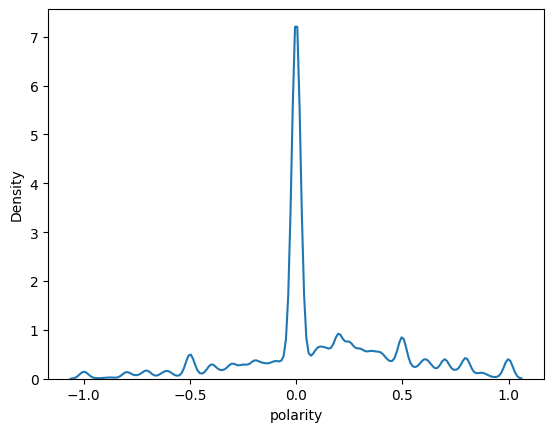

In [11]:
# Distribution of polarities
sns.kdeplot(data=clean_df, x='polarity')

In [12]:
pip install textstat

Note: you may need to restart the kernel to use updated packages.


In [13]:
def lexical_complexity(text):
    # Tokenize the text
    tokens = nltk.word_tokenize(text.lower())

    # Remove punctuation and stopwords
    words = [word for word in tokens if word.isalpha() and word not in stopwords.words('english')]

    # Calculate the number of words and sentences
    num_words = len(words)
    num_sentences = len(nltk.sent_tokenize(text))

    # Calculate the average words per sentence and syllables per word
    if num_sentences > 0:
        words_per_sentence = num_words / num_sentences
    else:
        words_per_sentence = 0
        
    if num_words > 0:
        syllables_per_word = sum([syllable_count(word) for word in words]) / num_words
    else:
        syllables_per_word = 0

    # Calculate the lexical complexity using the Flesch-Kincaid formula
    return 0.39 * words_per_sentence + 11.8 * syllables_per_word - 15.59

In [14]:
clean_df['lexical_complexity'] = clean_df['text'].apply(lexical_complexity)

In [15]:
clean_df

,id,created,query,user,text,polarity,lexical_complexity
0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,upset can't update Facebook texting it... migh...,0.0000,5.433333
1,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,dived many times ball. Managed save 50% rest g...,0.5000,-0.723889
2,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,whole body feels itchy like fire,0.2000,-1.450000
3,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"no, behaving all. i'm mad. here? can't see there.",-0.6250,2.500000
4,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,whole crew,0.2000,-3.010000
...,...,...,...,...,...,...,...
1599994,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,woke up. school best feeling ever,1.0000,1.905000
1599995,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - cool hear old Walt interviews! h...,0.2375,1.313333
1599996,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,ready MoJo Makeover? Ask details,0.2000,1.905000
1599997,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday boo alll time!!! Tupac Ama...,1.0000,3.670000


<AxesSubplot: xlabel='lexical_complexity', ylabel='Density'>

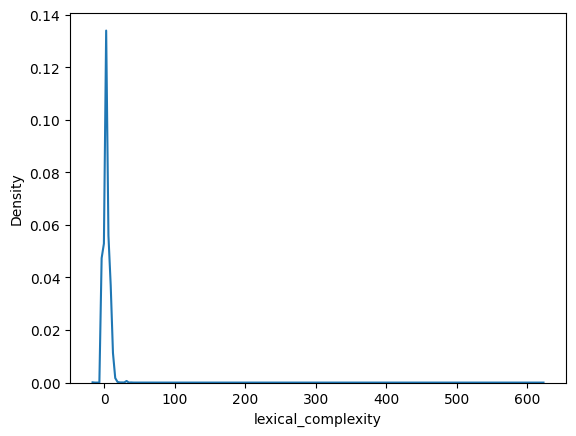

In [16]:
sns.kdeplot(data=clean_df, x='lexical_complexity')

In [17]:
clean_df

,id,created,query,user,text,polarity,lexical_complexity
0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,upset can't update Facebook texting it... migh...,0.0000,5.433333
1,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,dived many times ball. Managed save 50% rest g...,0.5000,-0.723889
2,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,whole body feels itchy like fire,0.2000,-1.450000
3,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"no, behaving all. i'm mad. here? can't see there.",-0.6250,2.500000
4,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,whole crew,0.2000,-3.010000
...,...,...,...,...,...,...,...
1599994,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,woke up. school best feeling ever,1.0000,1.905000
1599995,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - cool hear old Walt interviews! h...,0.2375,1.313333
1599996,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,ready MoJo Makeover? Ask details,0.2000,1.905000
1599997,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday boo alll time!!! Tupac Ama...,1.0000,3.670000


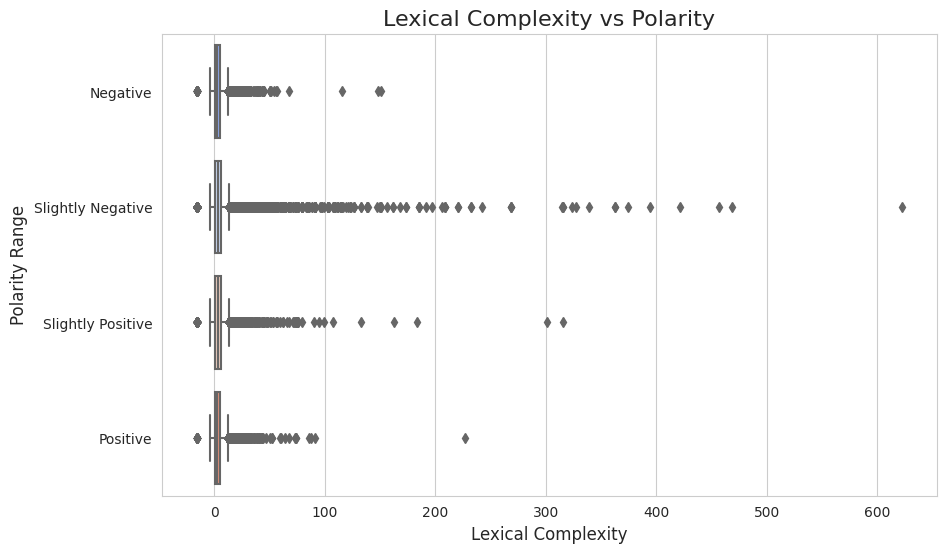

In [18]:
# Set the style of the plot
sns.set_style("whitegrid")

# Define the polarity ranges and corresponding labels
polarity_ranges = [-1, -0.5, 0, 0.5, 1]
polarity_labels = ['Negative', 'Slightly Negative', 'Slightly Positive','Positive']

# Add a new column for polarity ranges
clean_df['polarity_range'] = pd.cut(clean_df['polarity'], polarity_ranges, labels=polarity_labels)

# Create the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='lexical_complexity', y='polarity_range', data=clean_df, palette='coolwarm')

# Set the plot title and axis labels
plt.title('Lexical Complexity vs Polarity', fontsize=16)
plt.xlabel('Lexical Complexity', fontsize=12)
plt.ylabel('Polarity Range', fontsize=12)

# Show the plot
plt.show()


In [19]:
clean_df.shape

(1599999, 8)

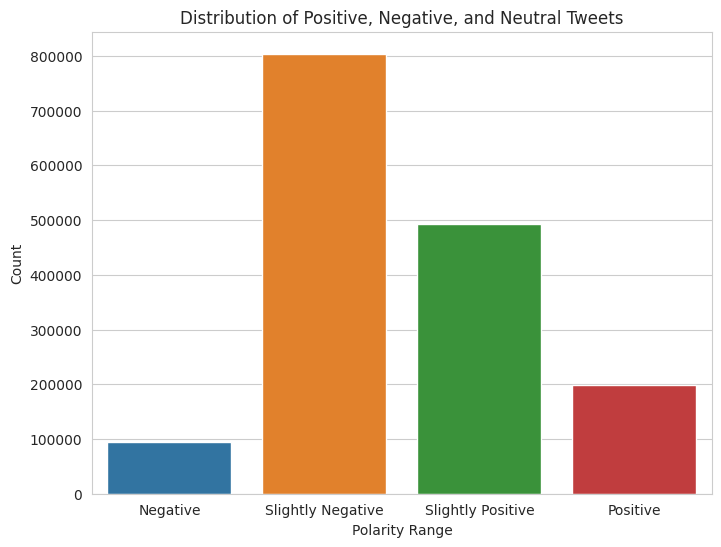

In [20]:
'''
polarity_ranges = [-1, -0.5, 0, 0.5, 1]
polarity_labels = ['Negative', 'Slightly Negative', 'Neutral', 'Slightly Positive','Positive']
'''

# Create a countplot
plt.figure(figsize=(8, 6))
sns.countplot(data=clean_df, x='polarity_range')

# Set the labels and title
plt.xlabel('Polarity Range')
plt.ylabel('Count')
plt.title('Distribution of Positive, Negative, and Neutral Tweets')

# Show the plot
plt.show()

Complejidad lectura/escritura: Que función o API usar para calcular que complejidad léxica (cuesta mucho de leer / no cuesta nada)
Dejo o no dejo los numbres de usuario en los tweets, punto, coma, raíz de los verbos, stop words, hashtags. Hashtags al final del tweet son tags.

**No es el numero de seguidores sino el número de menciones**

In [21]:
from collections import Counter

# Separate positive and negative tweets
positive_tweets = clean_df.loc[clean_df['polarity'] > 0, 'text']
negative_tweets = clean_df.loc[clean_df['polarity'] < 0, 'text']

# Tokenize positive tweets and count word frequencies
positive_words = []
for tweet in positive_tweets:
    positive_words.extend(tweet.lower().split())

positive_word_counts = Counter(positive_words)

# Tokenize negative tweets and count word frequencies
negative_words = []
for tweet in negative_tweets:
    negative_words.extend(tweet.lower().split())

negative_word_counts = Counter(negative_words)

# Get the most common words for positive and negative tweets
num_common_words = 10  # Number of most common words to retrieve

most_common_positive_words = positive_word_counts.most_common(num_common_words)
most_common_negative_words = negative_word_counts.most_common(num_common_words)

# Print the most common words for positive tweets
print("Most common words in positive tweets:")
for word, count in most_common_positive_words:
    print(word, count)

print("\n")

# Print the most common words for negative tweets
print("Most common words in negative tweets:")
for word, count in most_common_negative_words:
    print(word, count)

Most common words in positive tweets:
good 74829
i'm 59228
love 56773
lol 37969
new 36231
get 36224
- 35244
like 35024
really 33055
day 33024


Most common words in negative tweets:
i'm 37039
bad 18518
hate 17963
get 17934
sad 17434
like 17398
sorry 15534
im 15039
go 14793
got 13408


In [22]:
clean_df

,id,created,query,user,text,polarity,lexical_complexity,polarity_range
0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,upset can't update Facebook texting it... migh...,0.0000,5.433333,Slightly Negative
1,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,dived many times ball. Managed save 50% rest g...,0.5000,-0.723889,Slightly Positive
2,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,whole body feels itchy like fire,0.2000,-1.450000,Slightly Positive
3,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"no, behaving all. i'm mad. here? can't see there.",-0.6250,2.500000,Negative
4,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,whole crew,0.2000,-3.010000,Slightly Positive
...,...,...,...,...,...,...,...,...
1599994,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,woke up. school best feeling ever,1.0000,1.905000,Positive
1599995,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - cool hear old Walt interviews! h...,0.2375,1.313333,Slightly Positive
1599996,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,ready MoJo Makeover? Ask details,0.2000,1.905000,Slightly Positive
1599997,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday boo alll time!!! Tupac Ama...,1.0000,3.670000,Positive


## ¿Qué usuarios tienden a generar tweets con una polaridad más positiva o negativa?

In [23]:
# Agrupar los tweets por usuario y calcular la polaridad promedio
user_polarity = clean_df.groupby('user')['polarity'].mean()

# Ordenar los usuarios según su polaridad promedio
user_polarity_sorted = user_polarity.sort_values(ascending=False)

# Mostrar los usuarios con la polaridad más positiva
print("Usuarios con la media de polaridad más positiva:")
print(user_polarity_sorted.head(10))

# Mostrar los usuarios con la polaridad más negativa
print("Usuarios con la media de polaridad más negativa:")
print(user_polarity_sorted.tail(10))

Usuarios con la media de polaridad más positiva:
user
badhunsunshine    1.0
Donna711          1.0
Kat6479           1.0
VamoosRafa        1.0
morganfayne       1.0
ValiaKas          1.0
Donnaweathers     1.0
Donnavox          1.0
ValeriaVirguez    1.0
morgrochele21     1.0
Name: polarity, dtype: float64
Usuarios con la media de polaridad más negativa:
user
darienmoultrie    -1.0
LDLyons           -1.0
baabycd           -1.0
PaulCaudell       -1.0
fLowerfacEx       -1.0
kohkoh7           -1.0
thejohnsongroup   -1.0
Lozaardd          -1.0
twera             -1.0
Lilbugger         -1.0
Name: polarity, dtype: float64


## ¿Hay alguna relación entre la polaridad de los tweets y el número de menciones a un usuario?

In [24]:
# Calcular el número de menciones a cada usuario en los tweets
df['polarity'] = df['text'].apply(get_tweet_polarity)

user_mentions = df['text'].str.count('@\w+')

df['user_mentions'] = user_mentions

In [25]:
df

,id,created,query,user,text,polarity,user_mentions
0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,upset can't update Facebook texting it... migh...,0.0000,0
1,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,dived many times ball. Managed save 50% rest g...,0.5000,0
2,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,whole body feels itchy like fire,0.2000,0
3,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"no, behaving all. i'm mad. here? can't see there.",-0.6250,0
4,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,whole crew,0.2000,0
...,...,...,...,...,...,...,...
1599994,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,woke up. school best feeling ever,1.0000,0
1599995,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - cool hear old Walt interviews! h...,0.2375,0
1599996,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,ready MoJo Makeover? Ask details,0.2000,0
1599997,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday boo alll time!!! Tupac Ama...,1.0000,0


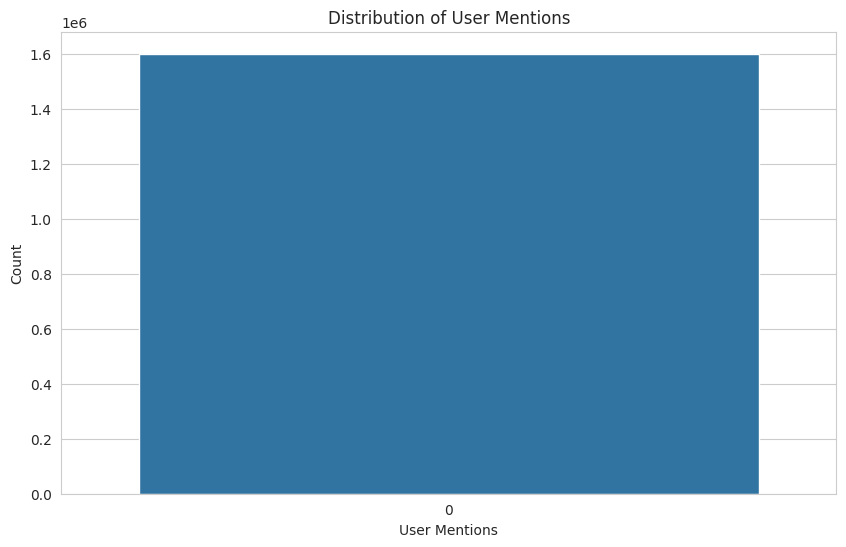

In [26]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='user_mentions')
plt.xlabel('User Mentions')
plt.ylabel('Count')
plt.title('Distribution of User Mentions')
plt.show()

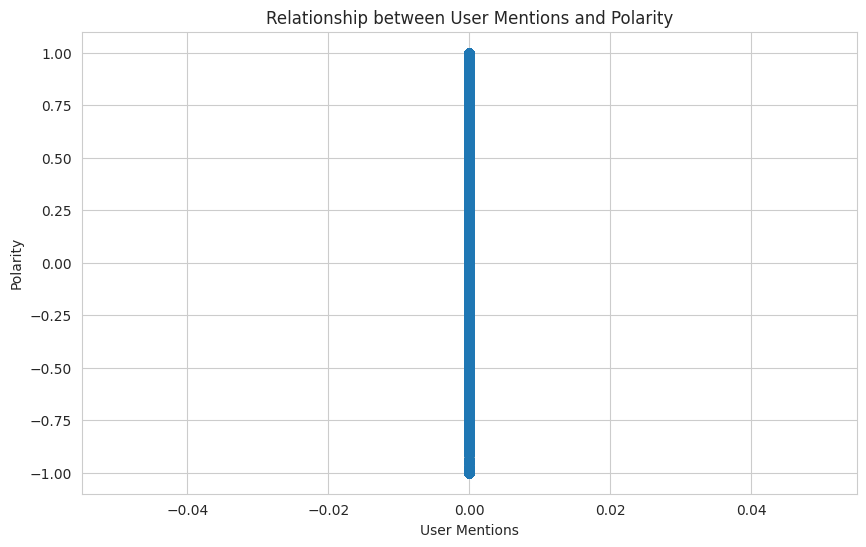

In [27]:
plt.figure(figsize=(10, 6))
plt.scatter(df['user_mentions'], df['polarity'], alpha=0.5)
plt.xlabel('User Mentions')
plt.ylabel('Polarity')
plt.title('Relationship between User Mentions and Polarity')
plt.show()

In [28]:
topic = 'youtube'
filtered_df = clean_df[clean_df['text'].str.contains(topic, case=False)]

In [29]:
filtered_df

,id,created,query,user,text,polarity,lexical_complexity,polarity_range
269,1467879328,Mon Apr 06 22:37:46 PDT 2009,NO_QUERY,flowerlilly,ooh Im excited even going 2 long love YOUTUBE!,0.316667,3.755000,Slightly Positive
410,1467916700,Mon Apr 06 22:48:00 PDT 2009,NO_QUERY,EricaLeigh777,KNOW! really surprised since everyone recommen...,0.100000,9.310000,Slightly Positive
475,1467931736,Mon Apr 06 22:52:19 PDT 2009,NO_QUERY,Gordie_Rogers,pity YouTube currently blocked China. can't se...,-0.050000,2.195000,Slightly Negative
1330,1468131477,Mon Apr 06 23:53:18 PDT 2009,NO_QUERY,foxythang2000,CURSE SLOW INTERNET. miss YouTube,-0.300000,1.905000,Slightly Negative
1343,1468133212,Mon Apr 06 23:53:53 PDT 2009,NO_QUERY,paul_steele,Please watch vid tell moved http://www.youtube...,0.000000,-1.450000,Slightly Negative
...,...,...,...,...,...,...,...,...
1596235,2192606432,Tue Jun 16 07:17:10 PDT 2009,NO_QUERY,kylaCschofield,watching http://bit.ly/L6OHo youtube!,0.000000,1.313333,Slightly Negative
1597479,2192937873,Tue Jun 16 07:46:04 PDT 2009,NO_QUERY,PotatoPeelPie,"Oh wow! know YouTube! knoooow you, walked upon...",0.156250,-1.275000,Slightly Positive
1597773,2193008450,Tue Jun 16 07:52:07 PDT 2009,NO_QUERY,tayloredwards,Http://www.YouTube.com/taylorlauren01 &lt;---c...,0.195312,-0.650000,Slightly Positive
1598935,2193306432,Tue Jun 16 08:16:41 PDT 2009,NO_QUERY,myfourthirds,Amazing BlendTec video YouTube associated E-P1...,0.750000,7.368571,Positive


In [30]:
from sklearn.cluster import KMeans
import numpy as np

# Obtén las polaridades de los tweets y los nombres de usuario
polarities = filtered_df.groupby('user')['polarity'].mean()
usernames = polarities.index

# Crea una matriz de características con las polaridades de los usuarios
X = np.array(polarities).reshape(-1, 1)

# Aplica el algoritmo de K-means para agrupar los usuarios
k = 3  # Número de clusters
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X)

# Obtiene las etiquetas de cluster asignadas a cada usuario
labels = kmeans.labels_

/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


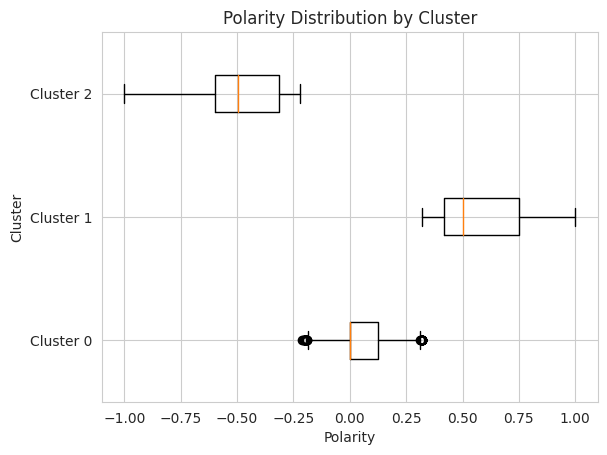

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Group the polarity by cluster labels
cluster_polarities = [polarities[labels == i] for i in range(k)]

# Create the boxplot
plt.boxplot(cluster_polarities, labels=['Cluster 0', 'Cluster 1', 'Cluster 2'], vert=False)

# Personalize the plot
plt.xlabel('Polarity')
plt.ylabel('Cluster')
plt.title('Polarity Distribution by Cluster')

# Show the plot
plt.show()

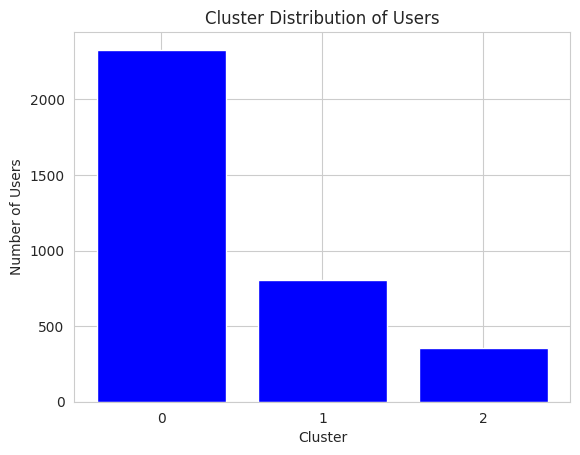

In [32]:
# Count the number of users in each cluster
cluster_counts = np.bincount(labels)

# Generate x-axis values for clusters
x = np.arange(len(cluster_counts))

# Create a bar plot of cluster counts
plt.bar(x, cluster_counts, color='blue')

# Personalize the plot
plt.xlabel('Cluster')
plt.ylabel('Number of Users')
plt.title('Cluster Distribution of Users')

# Set the x-axis tick labels as cluster numbers
plt.xticks(x)

# Show the plot
plt.show()

/opt/conda/lib/python3.10/site-packages/dateutil/parser/_parser.py:1207: UnknownTimezoneWarning: tzname PDT identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "


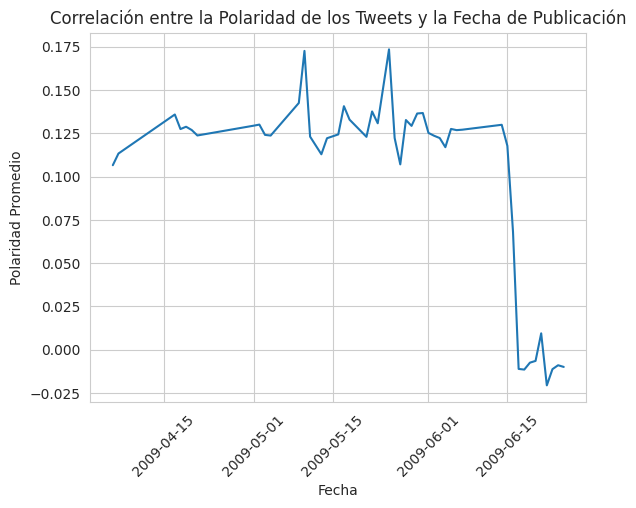

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

# Convertir la columna 'created' a formato de fecha y hora
clean_df['created'] = pd.to_datetime(clean_df['created'])

# Ordenar el DataFrame por la columna 'created'
clean_df.sort_values('created', inplace=True)

# Agrupar los tweets por fecha y calcular la media de la polaridad
grouped_data = clean_df.groupby(clean_df['created'].dt.date)['polarity'].mean()

# Crear el gráfico de línea
plt.plot(grouped_data.index, grouped_data.values)

# Personalizar el gráfico
plt.xlabel('Fecha')
plt.ylabel('Polaridad Promedio')
plt.title('Correlación entre la Polaridad de los Tweets y la Fecha de Publicación')

# Rotar las etiquetas del eje x para una mejor visibilidad
plt.xticks(rotation=45)

# Mostrar el gráfico
plt.show()

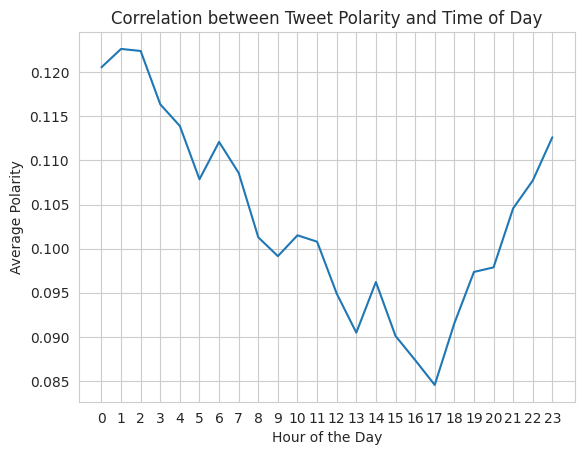

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert the 'created' column to datetime format
clean_df['created'] = pd.to_datetime(clean_df['created'])

# Extract the hour from the 'created' column
clean_df['hour'] = clean_df['created'].dt.hour

# Group the tweets by hour and calculate the average polarity
grouped_data = clean_df.groupby('hour')['polarity'].mean()

# Create the line plot
plt.plot(grouped_data.index, grouped_data.values)

# Customize the plot
plt.xlabel('Hour of the Day')
plt.ylabel('Average Polarity')
plt.title('Correlation between Tweet Polarity and Time of Day')

# Set the x-axis ticks to represent the 24 hours
plt.xticks(range(24))

# Show the plot
plt.show()


In [35]:
# Group by user and count the negative mentions
negative_mentions_by_user = df[df['polarity'] < 0].groupby('user')['user_mentions'].count()

# Sort the users based on the number of negative mentions
top_trolls = negative_mentions_by_user.sort_values(ascending=False).head(10)

print("\nTop 10 Trolls:")
for username, count in top_trolls.items():
    print(f"{username}: {count} negative mentions")



Top 10 Trolls:
what_bugs_u: 211 negative mentions
wowlew: 210 negative mentions
SallytheShizzle: 77 negative mentions
mcraddictal: 76 negative mentions
StDAY: 69 negative mentions
Spidersamm: 56 negative mentions
Dogbook: 50 negative mentions
ilostthegame: 47 negative mentions
dontforgetchaos: 45 negative mentions
SongoftheOss: 41 negative mentions


In [36]:
import re

df = pd.read_csv("/kaggle/input/tweets-dataset/training.1600000.processed.noemoticon.csv")
df.columns = ['polarity','id','created','query','user','text']
df.head()

# Define a regular expression pattern to match mentions
mention_pattern = r'@(\w+)'

# Extract all mentions from the text column
mentions = df['text'].str.extractall(mention_pattern)[0]

# Count the occurrences of each mentioned user
top_mentioned_users = mentions.value_counts().head(10)

print("\nTop Mentioned Users:")
print(top_mentioned_users)



Top Mentioned Users:
mileycyrus         4500
tommcfly           3887
ddlovato           3467
DavidArchie        1299
Jonasbrothers      1287
jordanknight       1130
DonnieWahlberg     1104
mitchelmusso       1077
JonathanRKnight    1074
taylorswift13      1011
Name: 0, dtype: int64
